In [ ]:
import numpy as np
import tvm
from tvm.script import tir as T

In [14]:
import IPython


def code2html(code):
    """Helper function to use pygments to turn the code string into highlighted html."""
    import pygments
    from pygments.formatters import HtmlFormatter
    from pygments.lexers import Python3Lexer

    formatter = HtmlFormatter(style="github-dark")
    html = pygments.highlight(code, Python3Lexer(), formatter)
    return "<style>%s</style>%s\n" % (formatter.get_style_defs(".highlight"), html)


In [4]:
@tvm.script.ir_module
class MyModule:
    @T.prim_func
    def main(
        A: T.Buffer((128, 128), "float32"),
        B: T.Buffer((128, 128), "float32"),
        C: T.Buffer((128, 128), "float32"),
    ):
        T.func_attr({"global_symbol": "main", "tirx.noalias": True})
        for i, j, k in T.grid(128, 128, 128):
            with T.sblock("C"):
                vi, vj, vk = T.axis.remap("SSR", [i, j, k])
                with T.init():
                    C[vi, vj] = 0.0
                C[vi, vj] = C[vi, vj] + A[vi, vk] * B[vk, vj]


In [5]:
dtype = "float32"
a_np = np.random.rand(128, 128).astype(dtype)
b_np = np.random.rand(128, 128).astype(dtype)
c_mm = a_np @ b_np


In [6]:
a_nd = tvm.runtime.tensor(a_np)
b_nd = tvm.runtime.tensor(b_np)
c_nd = tvm.runtime.tensor(np.empty((128, 128), dtype="float32"))

lib = tvm.compile(MyModule, target="llvm")
f_timer_before = lib.mod.time_evaluator("main", tvm.cpu())
print("Time cost of MyModule: %.3f ms" % (f_timer_before(a_nd, b_nd, c_nd).mean * 1000))


Time cost of MyModule: 2.074 ms


In [7]:
def schedule_mm(sch: tvm.s_tir.Schedule, jfactor=4):
    block_C = sch.get_sblock("C", "main")
    i, j, k = sch.get_loops(block=block_C)
    j_0, j_1 = sch.split(loop=j, factors=[None, jfactor])
    sch.reorder(i, j_0, k, j_1)
    sch.decompose_reduction(block_C, k)
    return sch


In [15]:
sch = tvm.s_tir.Schedule(MyModule)
sch = schedule_mm(sch)
IPython.display.HTML(code2html(sch.mod.script()))


In [16]:
lib = tvm.compile(sch.mod, target="llvm")
f_timer_after = lib.mod.time_evaluator("main", tvm.cpu())
print(
    "Time cost of MyModule=>schedule_mm: %.3f ms"
    % (f_timer_after(a_nd, b_nd, c_nd).mean * 1000)
)


Time cost of MyModule=>schedule_mm: 0.831 ms


### Trace


In [17]:
print(sch.trace)

# from tvm import s_tir
def apply_trace(sch: s_tir.Schedule) -> None:
  b0 = sch.get_sblock(name="C", func_name="main")
  l1, l2, l3 = sch.get_loops(block=b0)
  l4, l5 = sch.split(loop=l2, factors=[None, 4], preserve_unit_iters=True, disable_predication=False)
  sch.reorder(l1, l4, l3, l5)
  b6 = sch.decompose_reduction(block=b0, loop=l3)


In [18]:
def stochastic_schedule_mm(sch: tvm.s_tir.Schedule):
    block_C = sch.get_sblock("C", "main")
    i, j, k = sch.get_loops(block=block_C)
    j_factors = sch.sample_perfect_tile(loop=j, n=2)
    j_0, j_1 = sch.split(loop=j, factors=j_factors)
    sch.reorder(i, j_0, k, j_1)
    sch.decompose_reduction(block_C, k)
    return sch


In [19]:
sch = tvm.s_tir.Schedule(MyModule)
sch = stochastic_schedule_mm(sch)

IPython.display.HTML(code2html(sch.mod.script()))


In [28]:
sch = tvm.s_tir.Schedule(MyModule)
sch = stochastic_schedule_mm(sch)

IPython.display.HTML(code2html(sch.mod.script()))


In [29]:
print(sch.trace)


# from tvm import s_tir
def apply_trace(sch: s_tir.Schedule) -> None:
  b0 = sch.get_sblock(name="C", func_name="main")
  l1, l2, l3 = sch.get_loops(block=b0)
  v4, v5 = sch.sample_perfect_tile(loop=l2, n=2, max_innermost_factor=16, decision=[16, 8])
  l6, l7 = sch.split(loop=l2, factors=[v4, v5], preserve_unit_iters=True, disable_predication=False)
  sch.reorder(l1, l6, l3, l7)
  b8 = sch.decompose_reduction(block=b0, loop=l3)


In [30]:
sch = tvm.s_tir.Schedule(MyModule)
block_C = sch.get_sblock("C", "main")
i, j, k = sch.get_loops(block=block_C)
j_factors = sch.sample_perfect_tile(loop=j, n=2)


In [32]:
type(j_factors[0])


tvm.tir.expr.Var

In [33]:
print(sch.trace)


# from tvm import s_tir
def apply_trace(sch: s_tir.Schedule) -> None:
  b0 = sch.get_sblock(name="C", func_name="main")
  l1, l2, l3 = sch.get_loops(block=b0)
  v4, v5 = sch.sample_perfect_tile(loop=l2, n=2, max_innermost_factor=16, decision=[16, 8])


In [34]:
IPython.display.HTML(code2html(sch.mod.script()))


In [35]:
j_0, j_1 = sch.split(loop=j, factors=j_factors)
sch.reorder(i, j_0, k, j_1)


In [36]:
print(sch.trace)


# from tvm import s_tir
def apply_trace(sch: s_tir.Schedule) -> None:
  b0 = sch.get_sblock(name="C", func_name="main")
  l1, l2, l3 = sch.get_loops(block=b0)
  v4, v5 = sch.sample_perfect_tile(loop=l2, n=2, max_innermost_factor=16, decision=[16, 8])
  l6, l7 = sch.split(loop=l2, factors=[v4, v5], preserve_unit_iters=True, disable_predication=False)
  sch.reorder(l1, l6, l3, l7)


In [37]:
IPython.display.HTML(code2html(sch.mod.script()))


In [38]:
sch.reorder(i, j_0, k, j_1)
sch.decompose_reduction(block_C, k)


s_tir.SBlockRV(0x197c36c0)

In [39]:
IPython.display.HTML(code2html(sch.mod.script()))


In [40]:
def random_search(mod: tvm.IRModule, num_trials=5):
    best_result = None
    best_sch = None

    for i in range(num_trials):
        sch = stochastic_schedule_mm(tvm.s_tir.Schedule(mod))
        lib = tvm.compile(sch.mod, target="llvm")
        f_timer_after = lib.mod.time_evaluator("main", tvm.cpu())
        result = f_timer_after(a_nd, b_nd, c_nd).mean

        print("=====Attempt %d, time-cost: %.3f ms====" % (i, result * 1000))
        print(sch.trace)

        # book keep the best result so far
        if best_result is None or result < best_result:
            best_result = result
            best_sch = sch

    return best_sch


sch = random_search(MyModule)


=====Attempt 0, time-cost: 0.976 ms====
# from tvm import s_tir
def apply_trace(sch: s_tir.Schedule) -> None:
  b0 = sch.get_sblock(name="C", func_name="main")
  l1, l2, l3 = sch.get_loops(block=b0)
  v4, v5 = sch.sample_perfect_tile(loop=l2, n=2, max_innermost_factor=16, decision=[8, 16])
  l6, l7 = sch.split(loop=l2, factors=[v4, v5], preserve_unit_iters=True, disable_predication=False)
  sch.reorder(l1, l6, l3, l7)
  b8 = sch.decompose_reduction(block=b0, loop=l3)
=====Attempt 1, time-cost: 2.367 ms====
# from tvm import s_tir
def apply_trace(sch: s_tir.Schedule) -> None:
  b0 = sch.get_sblock(name="C", func_name="main")
  l1, l2, l3 = sch.get_loops(block=b0)
  v4, v5 = sch.sample_perfect_tile(loop=l2, n=2, max_innermost_factor=16, decision=[128, 1])
  l6, l7 = sch.split(loop=l2, factors=[v4, v5], preserve_unit_iters=True, disable_predication=False)
  sch.reorder(l1, l6, l3, l7)
  b8 = sch.decompose_reduction(block=b0, loop=l3)
=====Attempt 2, time-cost: 0.803 ms====
# from tvm impo

In [41]:
print(sch.trace)


# from tvm import s_tir
def apply_trace(sch: s_tir.Schedule) -> None:
  b0 = sch.get_sblock(name="C", func_name="main")
  l1, l2, l3 = sch.get_loops(block=b0)
  v4, v5 = sch.sample_perfect_tile(loop=l2, n=2, max_innermost_factor=16, decision=[32, 4])
  l6, l7 = sch.split(loop=l2, factors=[v4, v5], preserve_unit_iters=True, disable_predication=False)
  sch.reorder(l1, l6, l3, l7)
  b8 = sch.decompose_reduction(block=b0, loop=l3)


In [46]:
from tvm.s_tir import meta_schedule as ms

database = ms.tune_tir(
    mod=MyModule,
    target=tvm.target.Target({"kind": "llvm", "num-cores": 1}),
    max_trials_global=64,
    num_trials_per_iter=64,
    space=ms.space_generator.ScheduleFn(stochastic_schedule_mm),
    work_dir="./tune_tmp",
)

sch = ms.tir_integration.compile_tir(
    database, MyModule, tvm.target.Target({"kind": "llvm", "num-cores": 1})
)


2026-04-18 11:19:55 [INFO] Logging directory: ./tune_tmp/logs
2026-04-18 11:19:55 [INFO] LocalBuilder: max_workers = 8


[11:19:58] /workspace/tvm/src/target/llvm/llvm_instance.cc:219: Error: Using LLVM 19.1.7 with `-mcpu=apple-m1` is not valid in `-mtriple=arm64-apple-macos`, using default `-mcpu=generic`
[11:19:58] /workspace/tvm/src/target/llvm/llvm_instance.cc:219: Error: Using LLVM 19.1.7 with `-mcpu=apple-m1` is not valid in `-mtriple=arm64-apple-macos`, using default `-mcpu=generic`
[11:19:58] /workspace/tvm/src/target/llvm/llvm_instance.cc:219: Error: Using LLVM 19.1.7 with `-mcpu=apple-m2` is not valid in `-mtriple=arm64-apple-macos`, using default `-mcpu=generic`
[11:19:58] /workspace/tvm/src/target/llvm/llvm_instance.cc:219: Error: Using LLVM 19.1.7 with `-mcpu=apple-m2` is not valid in `-mtriple=arm64-apple-macos`, using default `-mcpu=generic`
[11:19:58] /workspace/tvm/src/target/llvm/llvm_instance.cc:219: Error: Using LLVM 19.1.7 with `-mcpu=apple-m1` is not valid in `-mtriple=arm64-apple-macos`, using default `-mcpu=generic`
[11:19:58] /workspace/tvm/src/target/llvm/llvm_instance.cc:219: E

2026-04-18 11:19:59 [INFO] LocalRunner: max_workers = 1
2026-04-18 11:20:02 [INFO] [task_scheduler.cc:171] Initializing Task #0: "main"


,Name,FLOP,Weight,Speed (GFLOPS),Latency (us),Weighted Latency (us),Trials,Done
0,main,4194304,1,N/A,N/A,N/A,0,


2026-04-18 11:20:02 [DEBUG] [task_scheduler.cc:330] 
 ID | Name |    FLOP | Weight | Speed (GFLOPS) | Latency (us) | Weighted Latency (us) | Trials | Done 
------------------------------------------------------------------------------------------------------
  0 | main | 4194304 |      1 |            N/A |          N/A |                   N/A |      0 |      
------------------------------------------------------------------------------------------------------
Total trials: 0
Total latency (us): 0


Total trials: 0
Total latency (us): 0

2026-04-18 11:20:02 [INFO] [task_scheduler.cc:192] TaskScheduler picks Task #0: "main"
2026-04-18 11:20:02 [INFO] [task_scheduler.cc:205] Sending 5 sample(s) to builder


...

2026-04-18 11:20:31 [DEBUG] [task_scheduler.cc:330] 
 ID | Name |    FLOP | Weight | Speed (GFLOPS) | Latency (us) | Weighted Latency (us) | Trials | Done 
------------------------------------------------------------------------------------------------------
  0 | main | 4194304 |      1 |        24.1619 |     173.5916 |              173.5916 |      5 |      
------------------------------------------------------------------------------------------------------
Total trials: 5
Total latency (us): 173.592


Total trials: 5
Total latency (us): 173.592

2026-04-18 11:20:31 [INFO] [task_scheduler.cc:192] TaskScheduler picks Task #0: "main"
2026-04-18 11:20:31 [INFO] [task_scheduler.cc:205] Sending 0 sample(s) to builder
2026-04-18 11:20:31 [INFO] [task_scheduler.cc:207] Sending 0 sample(s) to runner
2026-04-18 11:20:31 [INFO] [task_scheduler.cc:249] [Updated] Task #0: "main"


,Name,FLOP,Weight,Speed (GFLOPS),Latency (us),Weighted Latency (us),Trials,Done
0,main,4194304,1,24.1619,173.5916,173.5916,5,


2026-04-18 11:20:31 [DEBUG] [task_scheduler.cc:330] 
 ID | Name |    FLOP | Weight | Speed (GFLOPS) | Latency (us) | Weighted Latency (us) | Trials | Done 
------------------------------------------------------------------------------------------------------
  0 | main | 4194304 |      1 |        24.1619 |     173.5916 |              173.5916 |      5 |      
------------------------------------------------------------------------------------------------------
Total trials: 5
Total latency (us): 173.592


Total trials: 5
Total latency (us): 173.592

2026-04-18 11:20:31 [INFO] [task_scheduler.cc:192] TaskScheduler picks Task #0: "main"
2026-04-18 11:20:31 [INFO] [task_scheduler.cc:272] Task #0 has finished. Remaining task(s): 0


,Name,FLOP,Weight,Speed (GFLOPS),Latency (us),Weighted Latency (us),Trials,Done
0,main,4194304,1,24.1619,173.5916,173.5916,5,Y



Total trials: 5
Total latency (us): 173.592

2026-04-18 11:20:31 [DEBUG] [task_scheduler.cc:330] 
 ID | Name |    FLOP | Weight | Speed (GFLOPS) | Latency (us) | Weighted Latency (us) | Trials | Done 
------------------------------------------------------------------------------------------------------
  0 | main | 4194304 |      1 |        24.1619 |     173.5916 |              173.5916 |      5 |    Y 
------------------------------------------------------------------------------------------------------
Total trials: 5
Total latency (us): 173.592



In [50]:
import torch
import torchvision

test_data = torchvision.datasets.FashionMNIST(
    root="data", train=False, download=True, transform=torchvision.transforms.ToTensor()
)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=1, shuffle=True)
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

img, label = next(iter(test_loader))
img = img.reshape(1, 28, 28).numpy()


100.0%
100.0%
100.0%
100.0%


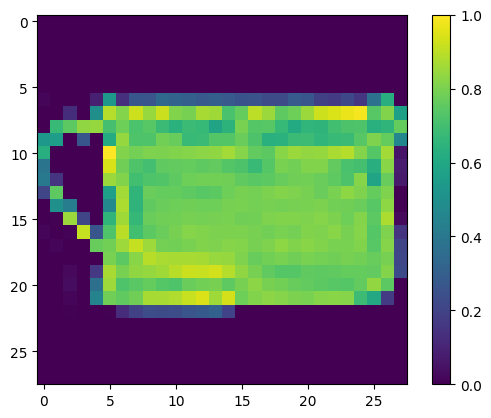

Class: Bag


In [51]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(img[0])
plt.colorbar()
plt.grid(False)
plt.show()

print("Class:", class_names[label[0]])


In [52]:
# Hide outputs
!wget -nc https://github.com/mlc-ai/web-data/raw/main/models/fasionmnist_mlp_params.pkl


--2026-04-18 11:22:15--  https://github.com/mlc-ai/web-data/raw/main/models/fasionmnist_mlp_params.pkl
Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/mlc-ai/web-data/main/models/fasionmnist_mlp_params.pkl [following]
--2026-04-18 11:22:15--  https://raw.githubusercontent.com/mlc-ai/web-data/main/models/fasionmnist_mlp_params.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 407396 (398K) [application/octet-stream]
Saving to: 'fasionmnist_mlp_params.pkl'

fasionmnist_mlp_par 100%[===================>] 397.85K  1.82MB/s    in 0.2s    



In [53]:
import pickle as pkl

mlp_params = pkl.load(open("fasionmnist_mlp_params.pkl", "rb"))

data_nd = tvm.runtime.tensor(img.reshape(1, 784))
nd_params = {k: tvm.runtime.tensor(v) for k, v in mlp_params.items()}


In [ ]:
from tvm import relax
from tvm.script import relax as R


@tvm.script.ir_module
class MyModuleMixture:
    @T.prim_func
    def linear0(
        X: T.Buffer((1, 784), "float32"),
        W: T.Buffer((128, 784), "float32"),
        B: T.Buffer((128,), "float32"),
        Z: T.Buffer((1, 128), "float32"),
    ):
        T.func_attr({"global_symbol": "linear0", "tirx.noalias": True})
        Y = T.alloc_buffer((1, 128), "float32")
        for i, j, k in T.grid(1, 128, 784):
            with T.sblock("Y"):
                vi, vj, vk = T.axis.remap("SSR", [i, j, k])
                with T.init():
                    Y[vi, vj] = T.float32(0)
                Y[vi, vj] = Y[vi, vj] + X[vi, vk] * W[vj, vk]

        for i, j in T.grid(1, 128):
            with T.sblock("Z"):
                vi, vj = T.axis.remap("SS", [i, j])
                Z[vi, vj] = Y[vi, vj] + B[vj]

    @R.function
    def main(
        x: R.Tensor((1, 784), "float32"),
        w0: R.Tensor((128, 784), "float32"),
        b0: R.Tensor((128,), "float32"),
        w1: R.Tensor((10, 128), "float32"),
        b1: R.Tensor((10,), "float32"),
    ):
        with R.dataflow():
            lv0 = R.call_dps_packed(
                "linear0", (x, w0, b0), R.Tensor((1, 128), dtype="float32")
            )
            lv1 = R.call_dps_packed(
                "env.relu", (lv0,), R.Tensor((1, 128), dtype="float32")
            )
            out = R.call_dps_packed(
                "env.linear", (lv1, w1, b1), R.Tensor((1, 10), dtype="float32")
            )
            R.output(out)
        return out


In [57]:
@tvm.register_global_func("env.linear", override=True)
def torch_linear(
    x: tvm.runtime.Tensor,
    w: tvm.runtime.Tensor,
    b: tvm.runtime.Tensor,
    out: tvm.runtime.Tensor,
):
    x_torch = torch.from_dlpack(x)
    w_torch = torch.from_dlpack(w)
    b_torch = torch.from_dlpack(b)
    out_torch = torch.from_dlpack(out)
    torch.mm(x_torch, w_torch.T, out=out_torch)
    torch.add(out_torch, b_torch, out=out_torch)


@tvm.register_global_func("env.relu", override=True)
def lnumpy_relu(x: tvm.runtime.Tensor, out: tvm.runtime.Tensor):
    x_torch = torch.from_dlpack(x)
    out_torch = torch.from_dlpack(out)
    torch.maximum(x_torch, torch.Tensor([0.0]), out=out_torch)


In [58]:
MyModuleWithParams = relax.transform.BindParams("main", nd_params)(MyModuleMixture)


In [59]:
target = tvm.target.Target("llvm", host="llvm")
ex = tvm.compile(MyModuleWithParams, target)
vm = relax.VirtualMachine(ex, tvm.cpu())

nd_res = vm["main"](data_nd)

pred_kind = np.argmax(nd_res.numpy(), axis=1)
print("MyModuleWithParams Prediction:", class_names[pred_kind[0]])


MyModuleWithParams Prediction: Bag


In [60]:
ftimer = vm.module.time_evaluator("main", tvm.cpu(), number=100)

print("MyModuleWithParams time-cost: %g ms" % (ftimer(data_nd).mean * 1000))


MyModuleWithParams time-cost: 0.164937 ms


In [61]:
mod_linear = tvm.IRModule.from_expr(
    MyModuleMixture["linear0"].with_attr("global_symbol", "main")
)
IPython.display.HTML(code2html(mod_linear.script()))


In [62]:
database = ms.tune_tir(
    mod=mod_linear,
    target=tvm.target.Target({"kind": "llvm", "num-cores": 1}),
    max_trials_global=64,
    num_trials_per_iter=64,
    work_dir="./tune_tmp",
)
sch = ms.tir_integration.compile_tir(
    database, mod_linear, tvm.target.Target({"kind": "llvm", "num-cores": 1})
)


2026-04-18 11:25:07 [INFO] Logging directory: ./tune_tmp/logs
2026-04-18 11:25:07 [INFO] LocalBuilder: max_workers = 8


[11:25:10] /workspace/tvm/src/target/llvm/llvm_instance.cc:219: Error: Using LLVM 19.1.7 with `-mcpu=apple-m1` is not valid in `-mtriple=arm64-apple-macos`, using default `-mcpu=generic`
[11:25:10] /workspace/tvm/src/target/llvm/llvm_instance.cc:219: Error: Using LLVM 19.1.7 with `-mcpu=apple-m1` is not valid in `-mtriple=arm64-apple-macos`, using default `-mcpu=generic`
[11:25:10] /workspace/tvm/src/target/llvm/llvm_instance.cc:219: Error: Using LLVM 19.1.7 with `-mcpu=apple-m2` is not valid in `-mtriple=arm64-apple-macos`, using default `-mcpu=generic`
[11:25:10] /workspace/tvm/src/target/llvm/llvm_instance.cc:219: Error: Using LLVM 19.1.7 with `-mcpu=apple-m2` is not valid in `-mtriple=arm64-apple-macos`, using default `-mcpu=generic`
[11:25:10] /workspace/tvm/src/target/llvm/llvm_instance.cc:219: Error: Using LLVM 19.1.7 with `-mcpu=apple-m1` is not valid in `-mtriple=arm64-apple-macos`, using default `-mcpu=generic`
[11:25:10] /workspace/tvm/src/target/llvm/llvm_instance.cc:219: E

2026-04-18 11:25:10 [INFO] LocalRunner: max_workers = 1
2026-04-18 11:25:13 [INFO] [task_scheduler.cc:171] Initializing Task #0: "main"


,Name,FLOP,Weight,Speed (GFLOPS),Latency (us),Weighted Latency (us),Trials,Done
0,main,200832,1,N/A,N/A,N/A,0,



Total trials: 0
Total latency (us): 0

2026-04-18 11:25:13 [DEBUG] [task_scheduler.cc:330] 
 ID | Name |   FLOP | Weight | Speed (GFLOPS) | Latency (us) | Weighted Latency (us) | Trials | Done 
-----------------------------------------------------------------------------------------------------
  0 | main | 200832 |      1 |            N/A |          N/A |                   N/A |      0 |      
-----------------------------------------------------------------------------------------------------
Total trials: 0
Total latency (us): 0

2026-04-18 11:25:13 [INFO] [task_scheduler.cc:192] TaskScheduler picks Task #0: "main"
2026-04-18 11:25:14 [INFO] [task_scheduler.cc:205] Sending 64 sample(s) to builder


...

2026-04-18 11:25:46 [INFO] [task_scheduler.cc:207] Sending 64 sample(s) to runner
2026-04-18 11:26:18 [DEBUG] XGB iter   0: tr-p-rmse: 0.301898	tr-a-peak@32: 1.000000	tr-rmse: 0.303679	tr-rmse: 0.303679
2026-04-18 11:26:18 [DEBUG] XGB iter  25: tr-p-rmse: 0.044708	tr-a-peak@32: 1.000000	tr-rmse: 0.363304	tr-rmse: 0.363304
2026-04-18 11:26:18 [DEBUG] XGB iter  50: tr-p-rmse: 0.044681	tr-a-peak@32: 1.000000	tr-rmse: 0.363367	tr-rmse: 0.363367
2026-04-18 11:26:18 [DEBUG] XGB iter  75: tr-p-rmse: 0.044681	tr-a-peak@32: 1.000000	tr-rmse: 0.363367	tr-rmse: 0.363367
2026-04-18 11:26:18 [DEBUG] XGB stopped. Best iteration: [34] tr-p-rmse:0.04468	tr-a-peak@32:1.00000	tr-rmse:0.36337	tr-rmse:0.36337 
2026-04-18 11:26:18 [INFO] [task_scheduler.cc:249] [Updated] Task #0: "main"


,Name,FLOP,Weight,Speed (GFLOPS),Latency (us),Weighted Latency (us),Trials,Done
0,main,200832,1,10.6037,18.9399,18.9399,64,


2026-04-18 11:26:18 [DEBUG] [task_scheduler.cc:330] 
 ID | Name |   FLOP | Weight | Speed (GFLOPS) | Latency (us) | Weighted Latency (us) | Trials | Done 
-----------------------------------------------------------------------------------------------------
  0 | main | 200832 |      1 |        10.6037 |      18.9399 |               18.9399 |     64 |      
-----------------------------------------------------------------------------------------------------
Total trials: 64
Total latency (us): 18.9399


Total trials: 64
Total latency (us): 18.9399

2026-04-18 11:26:18 [INFO] [task_scheduler.cc:272] Task #0 has finished. Remaining task(s): 0


,Name,FLOP,Weight,Speed (GFLOPS),Latency (us),Weighted Latency (us),Trials,Done
0,main,200832,1,10.6037,18.9399,18.9399,64,Y



Total trials: 64
Total latency (us): 18.9399

2026-04-18 11:26:18 [DEBUG] [task_scheduler.cc:330] 
 ID | Name |   FLOP | Weight | Speed (GFLOPS) | Latency (us) | Weighted Latency (us) | Trials | Done 
-----------------------------------------------------------------------------------------------------
  0 | main | 200832 |      1 |        10.6037 |      18.9399 |               18.9399 |     64 |    Y 
-----------------------------------------------------------------------------------------------------
Total trials: 64
Total latency (us): 18.9399



In [63]:
MyModuleWithParams2 = relax.transform.BindParams("main", nd_params)(MyModuleMixture)
new_func = sch.mod["main"].with_attr("global_symbol", "linear0")
gv = MyModuleWithParams2.get_global_var("linear0")
MyModuleWithParams2.update_func(gv, new_func)
IPython.display.HTML(code2html(MyModuleWithParams2.script()))


AttributeError: 'NoneType' object has no attribute 'mod'

In [ ]:
target = tvm.target.Target("llvm", host="llvm")
ex = tvm.compile(MyModuleWithParams2, target)
vm = relax.VirtualMachine(ex, tvm.cpu())

nd_res = vm["main"](data_nd)

pred_kind = np.argmax(nd_res.numpy(), axis=1)
print("MyModuleWithParams2 Prediction:", class_names[pred_kind[0]])


In [ ]:
ftimer = vm.module.time_evaluator("main", tvm.cpu(), number=50)

print("MyModuleWithParams2 time-cost: %g ms" % (ftimer(data_nd).mean * 1000))